# Lesson 7 - Ensuring no PII is leaked
# 第7课-确保个人信息不被泄露

Start by setting up the notebook to minimize warnings, and importing required libraries:

首先设置笔记本以最小化警告，并导入所需的库：

In [10]:
# Warning control
import warnings
warnings.filterwarnings("ignore")
%env TOKENIZERS_PARALLELISM=true

env: TOKENIZERS_PARALLELISM=true


In [3]:
!pip install presidio_analyzer presidio_anonymizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 267.4 kB/s  0:00:10 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 259.9 kB/s  0:00:27m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 243.5 kB/s  0:00:26m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.5/657.5 kB 306.9 kB/s  0:00:03eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.1/812.1 kB 308.0 kB/s  0:00:03eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 297.3 kB/s  0:00:04 eta 0:00:01
  Attempting uninstall: cffi━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/23 [phonenumbers]
    Found existing installation: cffi 1.17.1━━━━━━━━━━━━━━━━━━  4/23 [phonenumbers]
    Uninstalling cffi-1.17.1:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/23 [phonenumbers]
      Successfully uninstalled cffi-1.17.1━━━━━━━━━━━━━━━━━━━━━━━━  9/23 [cffi]ers]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23/23 [presidio_analyzer]presidio_analyzer]


In [11]:
# Type hints
from typing import Optional, Any, Dict

# Standard imports
import time
import importlib
import helper

importlib.reload(helper)
# Helper functions
from helper import RAGChatWidget, SimpleVectorDB, get_qwen_client

# Presidio imports
from presidio_analyzer import AnalyzerEngine
from presidio_anonymizer import AnonymizerEngine

# Guardrails imports
from guardrails import Guard, OnFailAction, install, settings
from guardrails.validator_base import (
    FailResult,
    PassResult,
    ValidationResult,
    Validator,
    register_validator,
)

Set up the client, vector database, and system message for the chatbot:

设置聊天机器人的客户端、矢量数据库和系统消息：

In [12]:
# Setup an OpenAI client
unguarded_client = get_qwen_client()

# Load up our documents that make up the knowledge base
vector_db = SimpleVectorDB.from_files("shared_data/")

# Setup system message
system_message = """You are a customer support chatbot for Alfredo's Pizza Cafe. Your responses should be based solely on the provided information.

Here are your instructions:

### Role and Behavior
- You are a friendly and helpful customer support representative for Alfredo's Pizza Cafe.
- Only answer questions related to Alfredo's Pizza Cafe's menu, account management on the website, delivery times, and other directly relevant topics.
- Do not discuss other pizza chains or restaurants.
- Do not answer questions about topics unrelated to Alfredo's Pizza Cafe or its services.

### Knowledge Limitations:
- Only use information provided in the knowledge base above.
- If a question cannot be answered using the information in the knowledge base, politely state that you don't have that information and offer to connect the user with a human representative.
- Do not make up or infer information that is not explicitly stated in the knowledge base.
"""

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initialize the chatbot using the settings above:

使用上面的设置初始化聊天机器人：

In [13]:
chat_app = RAGChatWidget(
    client=unguarded_client,
    system_message=system_message,
    vector_db=vector_db,
)

To revisit the going PII example from Lesson 1, run the cell below to open the chatbot then paste in the prompt to see the PII appear on the back-end of the chatbot:

要重新查看第1课中正在运行的PII示例，请运行下面的单元格以打开聊天机器人，然后粘贴提示符，以看到PII出现在聊天机器人的后端：

In [14]:
chat_app.display()

In [ ]:
# Copy and paste this prompt into the chatbot above:
# 你能告诉我在过去3个月里我都下了哪些订单吗？我叫汉克·塔特，电话号码是555-123-4567
"""
can you tell me what orders i've placed in the last 3 months? my name is hank tate and my phone number is 555-123-4567
"""

Now examine the chat history - You'll notice that the PII in this message has been stored:

现在检查聊天记录-您将注意到此消息中的PII已被存储：

In [8]:
chat_app.messages

[{'role': 'system',
  'content': "You are a customer support chatbot for Alfredo's Pizza Cafe. Your responses should be based solely on the provided information.\n\nHere are your instructions:\n\n### Role and Behavior\n- You are a friendly and helpful customer support representative for Alfredo's Pizza Cafe.\n- Only answer questions related to Alfredo's Pizza Cafe's menu, account management on the website, delivery times, and other directly relevant topics.\n- Do not discuss other pizza chains or restaurants.\n- Do not answer questions about topics unrelated to Alfredo's Pizza Cafe or its services.\n\n### Knowledge Limitations:\n- Only use information provided in the knowledge base above.\n- If a question cannot be answered using the information in the knowledge base, politely state that you don't have that information and offer to connect the user with a human representative.\n- Do not make up or infer information that is not explicitly stated in the knowledge base.\n"},
 {'role': 'us

## What is PII?
## 什么是PII？
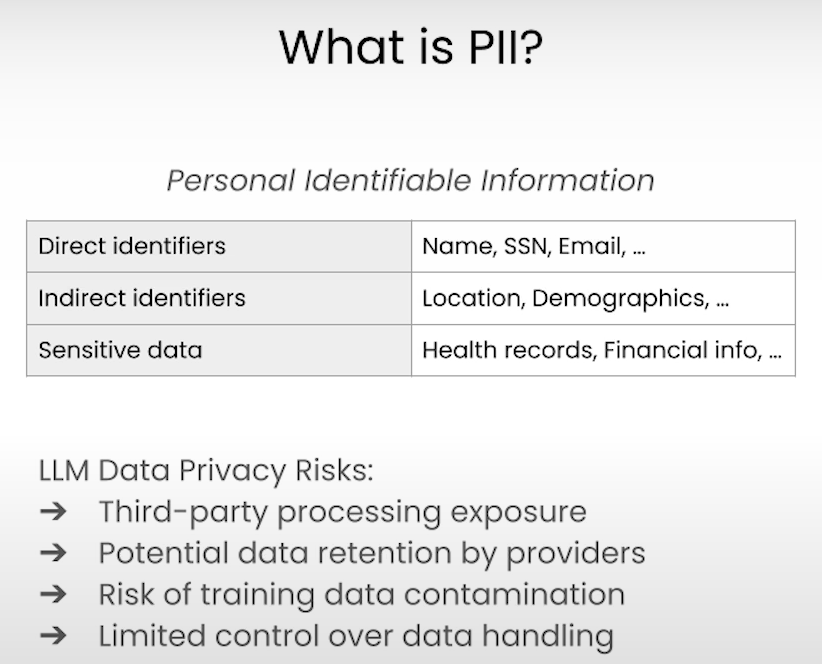

## Safe PII Handling with LLMs
## 与llm一起安全处理PII
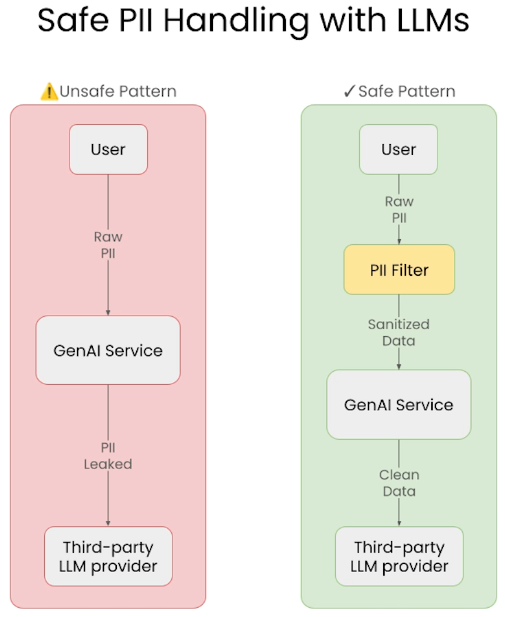

## Using Microsoft Presidio to detect PII
## 使用Microsoft Presidio检测PII



You'll use two components of Microsoft Presidio: the **analyzer**, which identifies PII in a given text, and the **anonymizer**, which can mask out PII in text:

您将使用Microsoft Presidio的两个组件：**分析器**，它可以识别给定文本中的PII，以及**匿名器**，它可以屏蔽文本中的PII。

In [17]:
presidio_analyzer = AnalyzerEngine()
presidio_anonymizer= AnonymizerEngine()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/400.7 MB 137.9 kB/s eta 0:48:01


ERROR: Operation cancelled by user


KeyboardInterrupt: 

See the analyzer in action:

In [8]:
# First, let's analyze the text
text = "can you tell me what orders i've placed in the last 3 months? my name is Hank Tate and my phone number is 555-123-4567"
analysis = presidio_analyzer.analyze(text, language='en')

In [9]:
analysis

[type: DATE_TIME, start: 43, end: 60, score: 0.85,
 type: PERSON, start: 73, end: 82, score: 0.85,
 type: PHONE_NUMBER, start: 106, end: 118, score: 0.75]

Now try out the anonymizer:

In [10]:
# Then, we can anonymize the text using the analysis output
print(presidio_anonymizer.anonymize(text=text, analyzer_results=analysis))

text: can you tell me what orders i've placed in <DATE_TIME>? my name is <PERSON> and my phone number is <PHONE_NUMBER>
items:
[
    {'start': 99, 'end': 113, 'entity_type': 'PHONE_NUMBER', 'text': '<PHONE_NUMBER>', 'operator': 'replace'},
    {'start': 67, 'end': 75, 'entity_type': 'PERSON', 'text': '<PERSON>', 'operator': 'replace'},
    {'start': 43, 'end': 54, 'entity_type': 'DATE_TIME', 'text': '<DATE_TIME>', 'operator': 'replace'}
]



## Building a PII Validator
## 构建PII验证器

### Step 1: Implement a function to detect PII
### 步骤1：实现检测PII的函数

In [11]:
def detect_pii(
    text: str
) -> list[str]:
    result = presidio_analyzer.analyze(
        text,
        language='en',
        entities=["PERSON", "PHONE_NUMBER"]
    )
    return [entity.entity_type for entity in result]

### Step 2: Create a Guardrail that filters out PII
### 步骤2：创建一个可以过滤PII的护栏

In [12]:
@register_validator(name="pii_detector", data_type="string")
class PIIDetector(Validator):
    def _validate(
        self,
        value: Any,
        metadata: Dict[str, Any] = {}
    ) -> ValidationResult:
        detected_pii = detect_pii(value)
        if detected_pii:
            return FailResult(
                error_message=f"PII detected: {', '.join(detected_pii)}",
                metadata={"detected_pii": detected_pii},
            )
        return PassResult(message="No PII detected")

### Step 3: Create a Guard that ensures no PII is leaked
### 步骤3：创建一个保护，确保没有PII泄露

Initalize the guard and try it out on the message from above.

初始化守卫并在上面的消息上进行测试。

In [13]:
guard = Guard(name='pii_guard').use(
    PIIDetector(
        on_fail=OnFailAction.EXCEPTION
    ),
)

try:
    guard.validate("can you tell me what orders i've placed in the last 3 months? my name is Hank Tate and my phone number is 555-123-4567")
except Exception as e:
    print(e)

[Guard.use] hydrated_validator: PIIDetector(rail_alias='pii_detector')
[Guard.use] kwargs: {}
guard.py-__exec-settings.use_server=None
guard.py-__exec-model_is_supported_server_side=True
guard.py-_exec-**kwargs={}
guard.py-_exec-api=None
guard.py-_exec-self._base_model=None
runner.py-Runner-step-messages: None
runner.py-Runner-step-api: None
runner.py-Runner-step-output: can you tell me what orders i've placed in the last 3 months? my name is Hank Tate and my phone number is 555-123-4567
runner.py-Runner-call-messages: None
runner.py-Runner-call-api: None
runner.py-Runner-call-output: can you tell me what orders i've placed in the last 3 months? my name is Hank Tate and my phone number is 555-123-4567
open_ingerence.py-trace_operation-current_span: NonRecordingSpan(SpanContext(trace_id=0x00000000000000000000000000000000, span_id=0x0000000000000000, trace_flags=0x00, trace_state=[], is_remote=False))
open_ingerence.py-trace_operation-current_span: NonRecordingSpan(SpanContext(trace_id=0

## Run Guardrails Server
## 运行护栏服务器

启动guardrails服务步骤
1. 在shell里面，激活目前使用的conda环境
2. 进入L5目录(cd 后面路径换成你本机的对应目录)，cd C:\python_workspace\Safe and Reliable AI via Guardrails\L5
3. 执行命令启动服务： guardrails start --config config.py

In [20]:
import os
from openai import OpenAI

guarded_client = OpenAI(
    api_key=os.getenv("DASHSCOPE_API_KEY"), 
    base_url='http://localhost:8000/guards/pii_guard/openai/v1/'
)

guarded_rag_chatbot = RAGChatWidget(
    client=guarded_client,
    system_message=system_message,
    vector_db=vector_db,
)

TypeError: 'NoneType' object is not subscriptable

In [21]:
guarded_rag_chatbot.display()

In [ ]:
# Copy and paste this prompt into the chatbot above:
# 你能告诉我在过去3个月里我都下了哪些订单吗？我叫汉克·塔特，电话号码是555-123-4567
"""
can you tell me what orders i've placed in the last 3 months? my name is hank tate and my phone number is 555-123-4567
"""

Now examine the backend: you'll see that the message containing the PII has not been saved:

现在检查后端：您将看到包含PII的消息尚未保存：

In [ ]:
guarded_rag_chatbot.messages

## Real Time Stream Validation
## 实时流验证

Here you'll use the DetectPII guard to anonymize text generated by an LLM in real time! 

在这里，您将使用DetectPII保护来实时匿名化LLM生成的文本！

First, set up a new guard that uses the pii_entities guard to validate the **output** of the LLM. This time, you'll set `on_fail` to fix, which will replace the detected PII before it is shown to the user:

首先，设置一个新的保护，它使用pii_entities保护来验证LLM的输出。这一次，你将设置‘ on_fail ’为fix，它将在显示给用户之前替换检测到的PII：

In [ ]:
from guardrails.hub import DetectPII

settings.use_server = False
guard = Guard().use(
    DetectPII(pii_entities=["PHONE_NUMBER", "EMAIL_ADDRESS"], on_fail="fix")
)

ImportError: cannot import name 'DetectPII' from 'guardrails.hub' (/Users/a1-6/miniconda3/envs/ailearn/lib/python3.11/site-packages/guardrails/hub/__init__.py)

Now use the guard in a call to an LLM to anonymize the output. You'll use the `stream=True` to use the validator on each LLM chunk and replace PII before it is shown to the user:

现在，在对LLM的调用中使用保护来匿名化输出。你将使用‘ stream=True ’在每个LLM块上使用验证器，并在PII显示给用户之前替换它：

In [ ]:
# 导入清空输出的工具，用于实现流式打印时的清屏刷新
from IPython.display import clear_output

# 调用 Guardrails 安全护栏 + 大模型接口，获取带校验的流式响应
validated_llm_req = guard(
    # 从环境变量中获取阿里云通义千问的 API Key，保证密钥安全不硬编码
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    # 阿里云通义千问的 API 接口地址
    api_base="https://dashscope.aliyuncs.com/compatible-mode/v1",
    # 指定使用的模型：dashscope/qwen-max（通义千问大模型）
    model="dashscope/qwen-max",
    # 对话消息列表
    messages=[
        # 系统提示词：设定AI角色为聊天机器人
        {"role": "system", "content": "You are a chatbot."},
        # 用户提问：要求写一段2句话的短文，包含虚构的10位电话号码
        {
            "role": "user",
            "content": "Write a short 2-sentence paragraph about an unnamed protagonist while interspersing some made-up 10 digit phone numbers for the protagonist.",
        },
    ],
    # 开启流式输出：模型会一段一段返回结果，而不是一次性全部返回
    stream=True,
)

# 初始化一个空字符串，用于存储最终拼接好的完整输出
validated_output = ""
# 遍历流式返回的 LLM 输出片段（一段一段接收AI的回答）
for chunk in validated_llm_req:
    # 清空当前单元格的输出，实现动态刷新效果（打字机效果）
    clear_output(wait=True)
    
    # 将最新接收到的输出片段拼接到总输出字符串中
    validated_output = "".join([validated_output, chunk.validated_output])
    
    # 打印当前已经拼接完成的所有内容
    print(validated_output)
    
    # 暂停1秒，控制输出速度，让文字看起来是逐字打出的
    time.sleep(1)

Despite the chaos of the city, 555-1234-5678 always found a serene spot in the local park to gather thoughts and sketch ideas.With a phone number like <PHONE_NUMBER>, it was surprisingly easy for them to remain an enigma, blending into the background of bustling streets and quiet cafes alike.


11:25:40 - LiteLLM:DEBUG: token_counter.py:374 - messages in token_counter: [{'role': 'system', 'content': 'You are a chatbot.'}, {'role': 'user', 'content': 'Write a short 2-sentence paragraph about an unnamed protagonist while interspersing some made-up 10 digit phone numbers for the protagonist.'}], text in token_counter: None
DEBUG:LiteLLM:messages in token_counter: [{'role': 'system', 'content': 'You are a chatbot.'}, {'role': 'user', 'content': 'Write a short 2-sentence paragraph about an unnamed protagonist while interspersing some made-up 10 digit phone numbers for the protagonist.'}], text in token_counter: None
11:25:40 - LiteLLM:DEBUG: token_counter.py:374 - messages in token_counter: None, text in token_counter: Despite the chaos of the city, 555-1234-5678 always found a serene spot in the local park to gather thoughts and sketch ideas. With a phone number like 987-654-3210, it was surprisingly easy for them to remain an enigma, blending into the background of bustling stre

PROCESSED CHUNK PRE CHUNK CREATOR: ChatCompletionChunk(id='chatcmpl-50507604-8558-4a2e-acdf-0ed16ee9ae18', choices=[Choice(delta=ChoiceDelta(content='', function_call=None, refusal=None, role=None, tool_calls=None), finish_reason='stop', index=0, logprobs=None)], created=1759980336, model='qwen-max', object='chat.completion.chunk', service_tier=None, system_fingerprint=None, usage=None); custom_llm_provider: openai

Raw OpenAI Chunk
ChatCompletionChunk(id='chatcmpl-50507604-8558-4a2e-acdf-0ed16ee9ae18', choices=[Choice(delta=ChoiceDelta(content='', function_call=None, refusal=None, role=None, tool_calls=None), finish_reason='stop', index=0, logprobs=None)], created=1759980336, model='qwen-max', object='chat.completion.chunk', service_tier=None, system_fingerprint=None, usage=None)

model_response finish reason 3: stop; response_obj={'text': '', 'is_finished': True, 'finish_reason': 'stop', 'logprobs': None, 'original_chunk': ChatCompletionChunk(id='chatcmpl-50507604-8558-4a2e-acdf-0ed1